---
title: "Lecture 26: Preconditioning"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture26_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Preconditioning

The convergence of Krylov methods can be expected to deteriorate as the condition number of the matrix increases. Even moderately large condition numbers can make the convergence impractically slow. 

. . .

Therefore it's common for these methods to be used with a technique to reduce the relevant condition number.

::: {.callout-note icon=false}
## Definition: Preconditioning
Given a linear system $\mathbf{A}\mathbf{x}=\mathbf{b}$, a **preconditioner** is a matrix $\mathbf{M}$ or equivalent linear transformation that modifies the system to be

$$(\mathbf{M}^{-1} \mathbf{A}) \mathbf{x} = \mathbf{M}^{-1}\mathbf{b}.$$
:::

. . .
 
More specifically, this is known as *left preconditioning*, but it is the simplest and most common type.

---

There are competing objectives in the choice of $\mathbf{M}$. On one hand, we want $\mathbf{M}^{-1}\mathbf{A}\approx \mathbf{I}$ in some sense because that makes the preconditioned system easy to solve by Krylov iteration. Hence $\mathbf{M}\approx \mathbf{A}$. 

. . .

On the other hand, we desire that solving a system defined with $\mathbf{M}$ be relatively fast. 

. . .

::: {.callout-warning icon=false}
## Fact: 
Good preconditioning is a matter of finding an easily inverted (i.e., quickly solvable) approximation of the original matrix. 
:::

## Diagonal preconditioning

One of the simplest choices for the preconditioner $\mathbf{M}$ is a diagonal matrix. This definitely meets the requirement of being fast to invert: the solution of $\mathbf{M}\mathbf{v}=\mathbf{y}$ is just $v_i=y_i/M_{ii}$. 

. . .

The only question is whether it can be chosen in such a way that $\mathbf{M}^{-1}\mathbf{A}$ is more amenable to Krylov iterations than $\mathbf{A}$ is. This may be the case when the rows of $\mathbf{A}$ differ greatly in scale, or when $\mathbf{A}$ is diagonally dominant.

. . .

In [24]:
# | echo: false
using LinearAlgebra
using MatrixDepot
using SparseArrays
using Preconditioners
using IterativeSolvers
using Plots
using IncompleteLU

In [12]:
# here is an SPD matrix that arises from solving partial differential equations
A = matrixdepot("wathen",60)
n = size(A,1)
@show n,nnz(A);

(n, nnz(A)) = (11041, 170161)


In [13]:
# you can take the diagonal elements of A as the preconditioner
b = ones(n)
M = DiagonalPreconditioner(diag(A));

---

(time_plain, time_prec) = (0.027308625, 0.009686125)


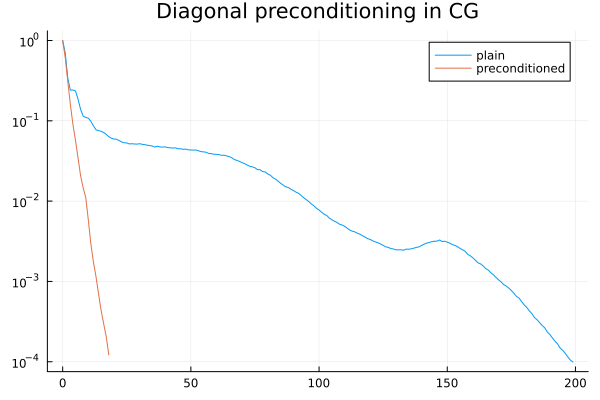

In [18]:
# compare CG with and without the preconditioner
plain(b) = cg(A,b,maxiter=200,reltol=1e-4,log=true)
time_plain = @elapsed x,hist1 = plain(b)
prec(b) = cg(A,b,Pl=M,maxiter=200,reltol=1e-4,log=true)
time_prec = @elapsed x,hist2 = prec(b)
@show time_plain,time_prec

rr = hist1[:resnorm]
plot(0:length(rr)-1,rr/rr[1],yscale=:log10,label="plain")
rr = hist2[:resnorm]
plot!(0:length(rr)-1,rr/rr[1],yscale=:log10,label="preconditioned")
title!("Diagonal preconditioning in CG")

. . .

The diagonal preconditioner cut down substantially on the number of iterations. The effect on the total time is less dramatic, but this is not a large version of the problem.

## Incomplete factorization

Another general-purpose technique is the **incomplete LU factorization**. Since true factorization of a sparse matrix usually leads to an undesirable amount of fill-in, incomplete LU sacrifices exact factors by dropping elements smaller than an adjustable threshold.

. . .

In [19]:
# this nonsymmetric matrix arising from a probabilistic model in 
# computational chemistry
A = sparse(matrixdepot("Watson/chem_master1"))
n = size(A,1)
@show n,nnz(A),issymmetric(A)

[ Info: downloading: https://sparse.tamu.edu/MM/Watson/chem_master1.tar.gz


(n, nnz(A), issymmetric(A)) = (40401, 201201, false)


(40401, 201201, false)

In [20]:
# without a preconditioner, GMRES makes essentially no progress after 100 iterations
b = rand(40000)
const GMRES = IterativeSolvers.gmres
x,history = GMRES(A,b,maxiter=100,reltol=1e-5,log=true)
resnorm = history[:resnorm]
@show resnorm[end] / resnorm[1];

resnorm[end] / resnorm[1] = 0.9685726368501838


. . .

The following version of incomplete LU factorization drops all sufficiently small values (i.e., replaces them with zeros). This keeps the number of nonzeros in the factors under control. 

In [25]:
iLU = ilu(A,τ=0.25)
@show nnz(iLU)/nnz(A);

nnz(iLU) / nnz(A) = 9.654509669435043


---

The result is almost 10 times as dense as $\mathbf{A}$ and yet still not a true factorization of it. However, it's close enough for an approximate inverse in a preconditioner. 

. . .

The actual preconditioning matrix is $\mathbf{M}=\mathbf{L}\mathbf{U}$, but we just supply the factorization to `gmres`.

In [26]:
_,history = GMRES(A,b,Pl=iLU,maxiter=100,reltol=1e-5,log=true)
history

Converged after 7 iterations.

. . .

The $\tau$ parameter in `ilu` balances the accuracy of the iLU factorization with the time needed to compute it and invert it. As $\tau\to 0$, more of the elements are kept, making the preconditioner more effective but slower per iteration.

---

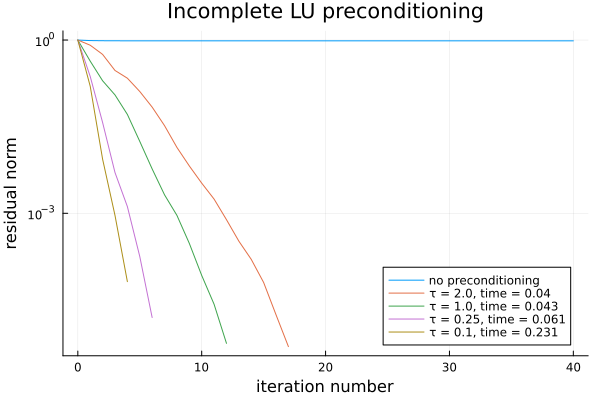

In [27]:
plt = plot(0:40,resnorm[1:41]/resnorm[1],label="no preconditioning",
        xaxis=("iteration number"),yaxis=(:log10,"residual norm"),
        leg=:bottomright,title="Incomplete LU preconditioning")
    for τ in [2,1,0.25,0.1]
        t = @elapsed iLU = ilu(A;τ)
        t += @elapsed _,history = GMRES(A,b,Pl=iLU,maxiter=100,
                                        reltol=1e-5,log=true)
        resnorm = history[:resnorm]
        label = "τ = $τ, time = $(round(t,digits=3))"
        plot!(0:length(resnorm)-1,resnorm/resnorm[1];label)
    end
plt

. . .

In any given problem, it's impossible to know in advance where the right balance lies between fidelity and speed for the preconditioner.

---

In practice, good preconditioning is often as important, if not more important, than the specific choice of Krylov method. 

. . .

Effective preconditioning may require deep understanding of the underlying application, however, which limits our ability to go into further details. For instance, the linear system may be some approximation of a continuous mathematical model, and then $\mathbf{M}$ can be derived by using a cruder form of the approximation. 

. . .

Krylov methods offer a natural way to exploit these and other approximate inverses.

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->